## Sberbank Russian Housing Market

Description:

Housing costs demand a significant investment from both consumers and developers. And when it comes to planning a budget—whether personal or corporate—the last thing anyone needs is uncertainty about one of their biggets expenses. Sberbank, Russia’s oldest and largest bank, helps their customers by making predictions about realty prices so renters, developers, and lenders are more confident when they sign a lease or purchase a building.

Although the housing market is relatively stable in Russia, the country’s volatile economy makes forecasting prices as a function of apartment characteristics a unique challenge. Complex interactions between housing features such as number of bedrooms and location are enough to make pricing predictions complicated. Adding an unstable economy to the mix means Sberbank and their customers need more than simple regression models in their arsenal.

In this competition, Sberbank is challenging Kagglers to develop algorithms which use a broad spectrum of features to predict realty prices. Competitors will rely on a rich dataset that includes housing data and macroeconomic patterns. An accurate forecasting model will allow Sberbank to provide more certainty to their customers in an uncertain economy.

Evaluation:

Submissions are evaluated on the RMSLE between their predicted prices and the actual data. The target variable, called price_doc in the training set, is the sale price of each property.

Submission File

For each id in the test set, you must predict the price that the property sold for. The file should contain a header and have the following format:

id,price_doc

30474,7118500.44

30475,7118500.44

30476,7118500.44

etc.

### Error Formula
The RMSLE is calculated as

$$
\epsilon = \sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }
$$

Where:

\\(\epsilon\\) is the RMSLE value (score)

\\(n\\) is the total number of observations in the (public/private) data set,

\\(p_i\\) is your prediction,

\\(a_i\\) is the actual response  for  \\(i\\).
 
\\(\log(x)\\) is the natural logarithm of \\(x\\)

**Notes:**

 - RMSLE penalizes an under-predicted estimate greater than an over-predicted estimate

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from sklearn.svm import SVR
from sklearn import svm

In [3]:
data_macro = pd.read_csv('/home/ajsg/Documents/Dataset/Kaggle/SberbankRussianHousingMarket/macro.csv', index_col='timestamp')
data_train = pd.read_csv('/home/ajsg/Documents/Dataset/Kaggle/SberbankRussianHousingMarket/train.csv')
data_test = pd.read_csv('/home/ajsg/Documents/Dataset/Kaggle/SberbankRussianHousingMarket/test.csv')
data_train.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000
1,2,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,...,15,3,0,15,29,1,10,66,14,6000000
2,3,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,...,10,3,0,11,27,0,4,67,10,5700000
3,4,2011-09-01,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,...,11,2,1,4,4,0,0,26,3,13100000
4,5,2011-09-05,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,...,319,108,17,135,236,2,91,195,14,16331452


In [4]:
data_macro.tail()

,oil_urals,gdp_quart,gdp_quart_growth,cpi,ppi,gdp_deflator,balance_trade,balance_trade_growth,usdrub,eurrub,...,provision_retail_space_modern_sqm,turnover_catering_per_cap,theaters_viewers_per_1000_cap,seats_theather_rfmin_per_100000_cap,museum_visitis_per_100_cap,bandwidth_sports,population_reg_sports_share,students_reg_sports_share,apartment_build,apartment_fund_sqm
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-10-15,44.3677,19979.4,-0.6,531.0,601.9,133.16,5.823,2.6,62.9573,69.0250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-16,44.3677,19979.4,-0.6,531.0,601.9,133.16,5.823,2.6,62.9573,69.0250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-17,44.3677,19979.4,-0.6,531.0,601.9,133.16,5.823,2.6,63.0856,69.3953,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-18,44.3677,19979.4,-0.6,531.0,601.9,133.16,5.823,2.6,62.9512,69.1790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-19,44.3677,19979.4,-0.6,531.0,601.9,133.16,5.823,2.6,62.9512,69.1790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Slicing data_macro to the same date that our sample
data_macro = data_macro.ix[:'2016-05-31',:]
data_macro.tail()

,oil_urals,gdp_quart,gdp_quart_growth,cpi,ppi,gdp_deflator,balance_trade,balance_trade_growth,usdrub,eurrub,...,provision_retail_space_modern_sqm,turnover_catering_per_cap,theaters_viewers_per_1000_cap,seats_theather_rfmin_per_100000_cap,museum_visitis_per_100_cap,bandwidth_sports,population_reg_sports_share,students_reg_sports_share,apartment_build,apartment_fund_sqm
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-05-27,45.0185,18561.3,-1.2,523.2,584.0,133.16,7.439,8.0,65.9385,73.2557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-28,45.0185,18561.3,-1.2,523.2,584.0,133.16,7.439,8.0,65.9385,73.2557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-29,45.0185,18561.3,-1.2,523.2,584.0,133.16,7.439,8.0,65.9385,73.2557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-30,45.0185,18561.3,-1.2,523.2,584.0,133.16,7.439,8.0,65.6745,73.1241,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-31,45.0185,18561.3,-1.2,523.2,584.0,133.16,7.439,8.0,66.0183,73.5330,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data_macro.apply(lambda x:set(x))

oil_urals                                     {29.1125, 107.4, 107.9176, 107.1991, 107.988, ...
gdp_quart                                     {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
gdp_quart_growth                              {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
cpi                                           {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
ppi                                           {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
gdp_deflator                                  {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
balance_trade                                 {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
balance_trade_growth                          {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
usdrub                                        {nan, nan, nan, 27.68, 28.3294, 29.6613, 30.69...
eurrub                                        {nan, nan, nan, 73.0964, 37.9445, 38.713, 39.6...
brent                                   

In [6]:
data_train.apply(lambda x:set(x))

id                                       {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
timestamp                                {2012-02-09, 2012-12-04, 2015-03-03, 2011-09-2...
full_sq                                  {0, 1, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17...
life_sq                                  {nan, 1.0, nan, nan, nan, nan, 0.0, nan, 8.0, ...
floor                                    {nan, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...
max_floor                                {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
material                                 {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
build_year                               {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
num_room                                 {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
kitch_sq                                 {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
state                                    {nan, nan, nan, nan, nan, nan, nan, nan, nan, ...

In [53]:
data_train[0:50].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Columns: 292 entries, id to price_doc
dtypes: float64(119), int64(157), object(16)
memory usage: 114.1+ KB


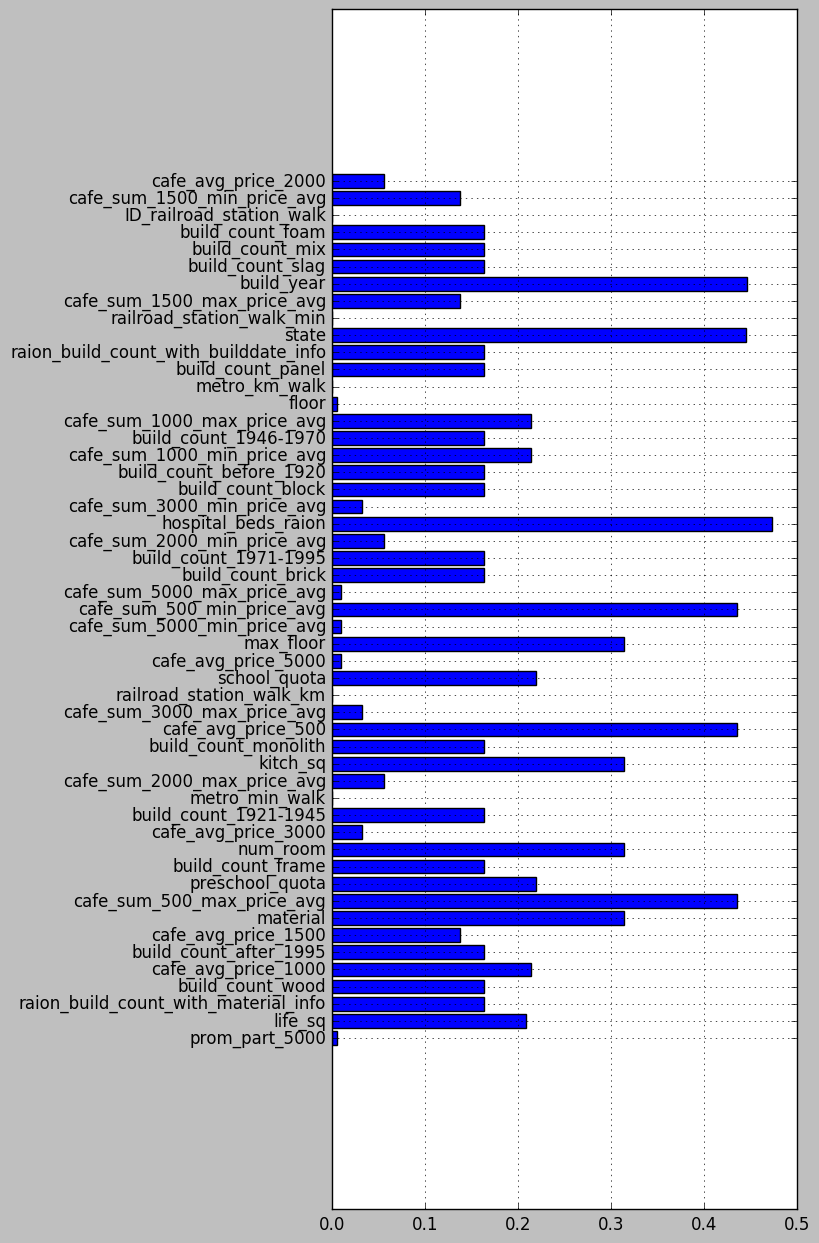

In [7]:
# NaN 
# num of nan: df.isnull().T.any().T.sum()
# returns a df with the rows with NaN: datanans = data[data.isnull().T.any().T]
dict_nan1 = {}

for i in data_train.columns:
    percent = data_train[i].isnull().sum()/len(data_train)
    if percent > 0:
        dict_nan1[i] = percent

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(6, 15))
y_pos = np.arange(len(dict_nan1))
ax.barh(y_pos, dict_nan1.values(), align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dict_nan1.keys())

plt.grid()
plt.show()

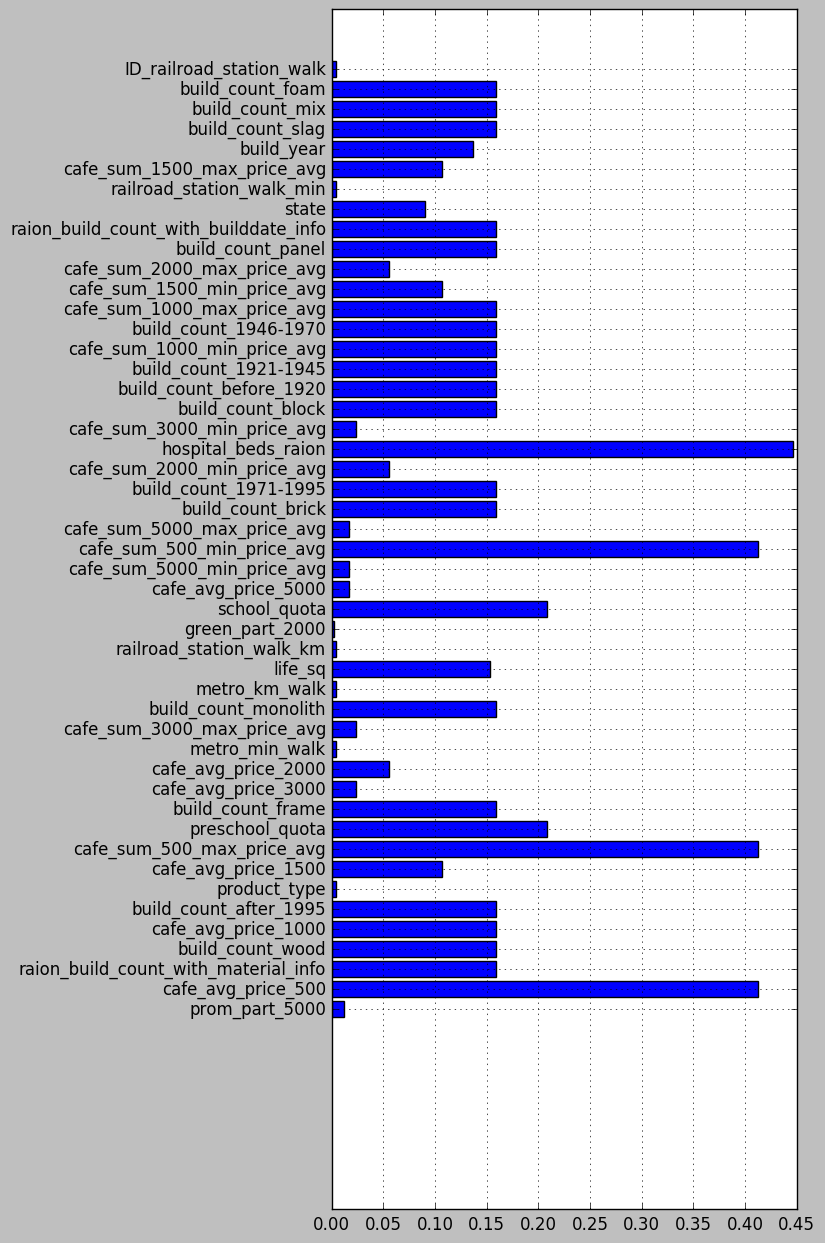

In [8]:
dict_nan2 = {}

for i in data_test.columns:
    percent = data_test[i].isnull().sum()/len(data_test)
    if percent > 0:
        dict_nan2[i] = percent

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(6, 15))
y_pos = np.arange(len(dict_nan2))
ax.barh(y_pos, dict_nan2.values(), align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dict_nan2.keys())
plt.grid()
plt.show()

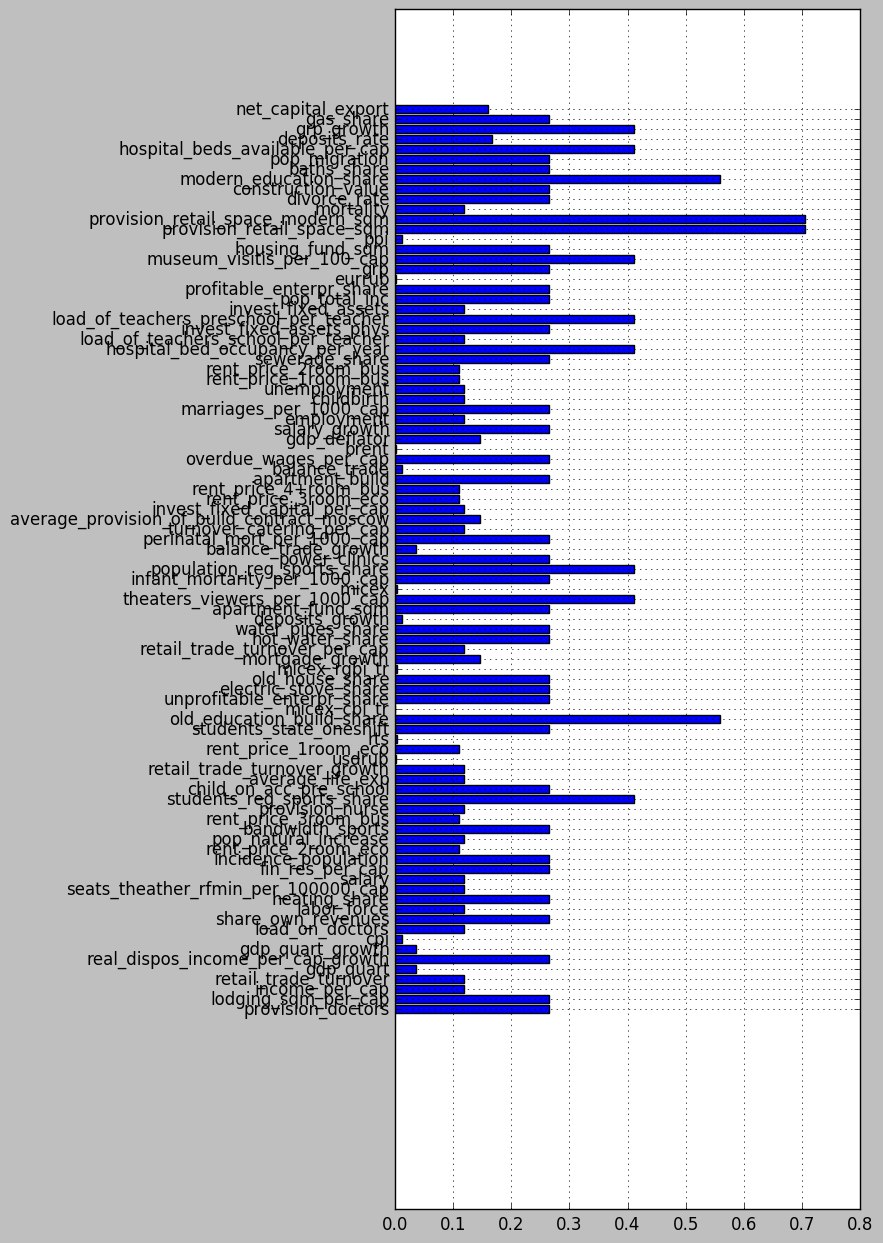

In [19]:
dict_nan3 = {}

for i in data_macro.columns:
    percent = data_macro[i].isnull().sum()/len(data_macro)
    if percent > 0:
        dict_nan3[i] = percent

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(6, 15))
y_pos = np.arange(len(dict_nan3))
ax.barh(y_pos, dict_nan3.values(), align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dict_nan3.keys())
plt.grid()
plt.show()

In [8]:
data_train['Price/full_sq'] = data_train['price_doc']/data_train['full_sq']

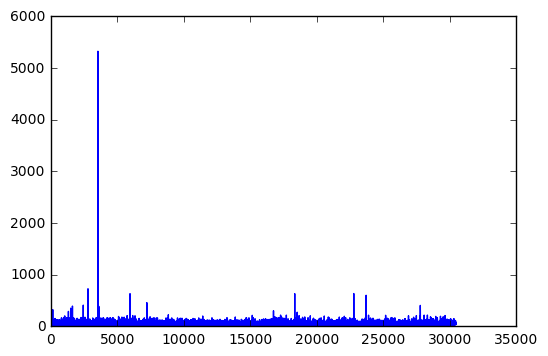

In [68]:
# Plotting the size data_train
plt.plot(data_train['full_sq'])
#plt.yscale('log')
plt.show()

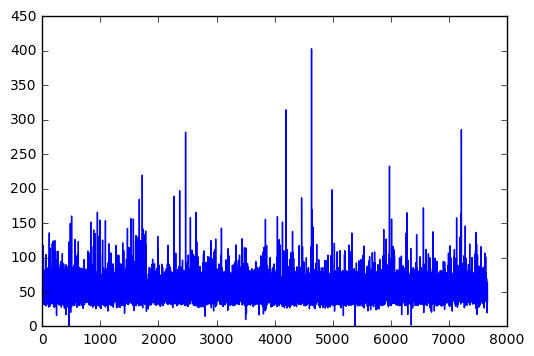

In [69]:
# plotting the size data_test
plt.plot(data_test['full_sq'])
plt.show()

In [70]:
# watching the bigger one
data_train.loc[data_train['full_sq'] == data_train['full_sq'].max()]

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc,Price/full_sq
3527,3530,2012-09-07,5326,22.0,13.0,NaN,NaN,NaN,NaN,NaN,...,2,0,5,16,0,2,43,6,6868818,1289.67668


In [71]:
# Other transaction the same day
data_train.loc[data_train['timestamp'] == '2012-09-07']

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc,Price/full_sq
3513,3516,2012-09-07,57,NaN,14.0,NaN,NaN,NaN,NaN,NaN,...,1,0,1,7,0,0,6,0,4467255,78372.894737
3514,3517,2012-09-07,44,29.0,4.0,NaN,NaN,NaN,NaN,NaN,...,4,0,7,10,0,2,34,0,6500000,147727.272727
3515,3518,2012-09-07,50,NaN,5.0,NaN,NaN,NaN,NaN,NaN,...,0,0,1,6,1,0,13,1,3560013,71200.260000
3516,3519,2012-09-07,31,20.0,1.0,NaN,NaN,NaN,NaN,NaN,...,8,2,23,42,1,14,78,12,5300000,170967.741935
3517,3520,2012-09-07,38,19.0,2.0,NaN,NaN,NaN,NaN,NaN,...,1,0,5,9,0,2,17,6,5150000,135526.315789
3518,3521,2012-09-07,78,NaN,9.0,NaN,NaN,NaN,NaN,NaN,...,2,1,5,4,0,1,32,5,10455680,134047.179487
3519,3522,2012-09-07,23,15.0,1.0,NaN,NaN,NaN,NaN,NaN,...,5,1,5,14,0,1,57,3,2000000,86956.521739
3520,3523,2012-09-07,90,57.0,3.0,NaN,NaN,NaN,NaN,NaN,...,0,0,2,2,0,1,6,1,14600000,162222.222222
3521,3524,2012-09-07,37,22.0,2.0,NaN,NaN,NaN,NaN,NaN,...,3,0,15,30,1,10,62,14,7600000,205405.405405
3522,3525,2012-09-07,63,NaN,11.0,NaN,NaN,NaN,NaN,NaN,...,1,0,1,7,0,0,6,0,5483719,87043.158730


In [4]:
# Dropping the bigger one because it is likely a mistake
data_train = data_train.drop(3527)

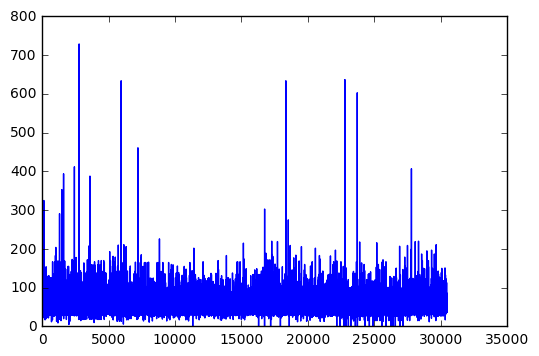

In [73]:
# Plotting the size data_train
plt.plot(data_train['full_sq'])
plt.show()

In [74]:
# How many houses are bigger than 450?
len(data_train.loc[data_train['full_sq'] >= 450])

6

In [75]:
# How many areas
len(set(data_train['sub_area']))

146

In [76]:
# How many areas
len(set(data_test['sub_area']))

145

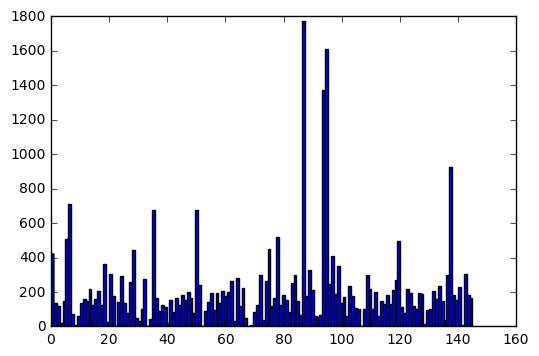

In [5]:
#### How many houses per area

# Enumerate areas train
for i,j in enumerate(set(data_train['sub_area'])):
    data_train.loc[data_train['sub_area'] == j, 'sub_area'] = i
    data_test.loc[data_test['sub_area'] == j, 'sub_area'] = i
    
plt.hist(data_train['sub_area'], len(set(data_train['sub_area'])))
plt.show()

In [78]:
np.histogram(data_train['sub_area'], len(set(data_train['sub_area'])))[0]

array([  34,  164,  206,  451,   99,  247, 1776,  139,  297,  105,  158,
          7,  259,    3,   50,   20,  678,  149,  154,  925,  362,  155,
         81,  295,  123,  230,   60,  165,  111,  241,  298,  211,  175,
         64,  100,  327,  273,  190,  135,   72,  255,  137,  180,  103,
        142,  121,   79,  213,   44,  282,  679,   56,   85,  237,  100,
         94,   90,  199,  200,  300,  188,  118, 1611,   60,  421,  182,
        100,  116,  126,  220,  508,  192,   79,  264,  148,  208,  127,
        201,   85,  174,  518,  177,  220,   77,  152,  305,  119,   19,
        713,  101,  131,    6,    2,  301,  182,   92,  443,  496,  262,
        167,  131,  353,  305,    2,   62,  147,  126,  196,   37,  267,
        220,  158,  143,  184,  135,  158,  178,  224,  173,  154,   27,
        147,  197,  166,  115,  207,  197,   98,    7,  126,   68,   31,
        148,   37, 1372,  136,    1,  237,   58,    1,  123,  410,  185,
         15,  163,   49])

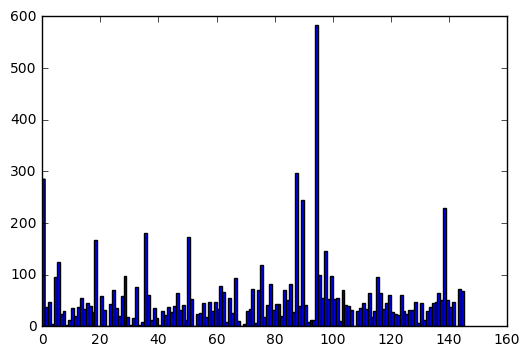

In [6]:
# Enumerate areas test
plt.hist(data_test['sub_area'], len(set(data_test['sub_area'])))
plt.show()

In [80]:
np.histogram(data_test['sub_area'], len(set(data_test['sub_area'])))[0]

array([  9,  60,  47, 118,  31,  55, 297,  36,  72,  39,  20,   2,  59,
         1,  18,   3, 181,  48,  29, 229, 167,  44,  20,  70,  34,  47,
        13,  42,  16,  53,  35,  46,  40,  28,  32, 244,  77,  53,  54,
        29,  71,  36,  52,  33,  26,  19,  23,  41,   8,  55, 173,  13,
        29,  70,  16,  19,  24,  79,  64,  51,  47,  26,  99,  10, 285,
        39,  12,  24,  28,  60, 125,  46,  20,  67,  95,  40,  35,  32,
        22,  34,  82,  41,  55,  12,  38,  72,  47,   4,  25,  30,  34,
         1,   2,  52,  26,  13,  98,  28,  71,  41,  95,  97,  58,   1,
        18,  37,  28,  29,  64,  60,  46,  37,  43,  65,  38,  45,  32,
        94,  55,  65,   1,  30,  32,  37,  25,  30,  48,  45,   5,  34,
        12,   2,  83,   7, 584,  29,   0,  45,   8,   1,  31, 146,  43,
         7,  52])

In [9]:
# Grouping areas with similar price caracteristics
areas_stat = data_train[['sub_area', 'Price/full_sq']].groupby(['sub_area'], as_index=False).mean()
std = data_train[['sub_area', 'Price/full_sq']].groupby(['sub_area'], as_index=False).std()
areas_stat['std'] = std.ix[:,1]
areas_stat['std/price'] = areas_stat['std'] / areas_stat['Price/full_sq'] 
areas_stat.head()

,sub_area,Price/full_sq,std,std/price
0,0,113896.106001,3.481062e+04,0.305635
1,1,272691.786009,1.454318e+06,5.333193
2,2,154613.072441,5.333716e+04,0.344972
3,3,99360.026368,3.603649e+04,0.362686
4,4,56482.897496,7.035904e+03,0.124567


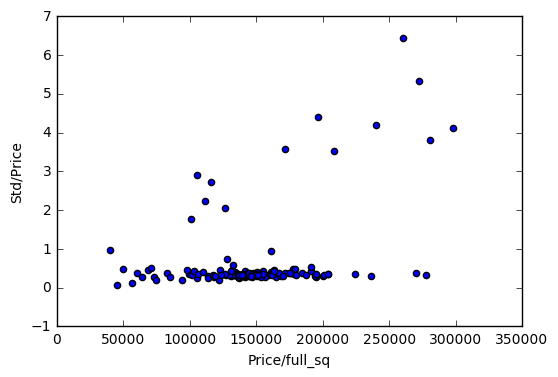

In [12]:
plt.scatter(areas_stat.ix[:,1], areas_stat.ix[:,3])
plt.xlabel('Price/full_sq')
plt.ylabel('Std/Price')
#plt.yscale('log')
plt.show()

In [13]:
data_train['Price/full_sq'].mean()

inf

In [194]:
# Plotting price evolution by areas

fig, axes = plt.subplots(15, 10, figsize=(12, 15), sharey=False)
axes = axes.ravel()
for i in range(len(areas_stat)):
    print(i)
    y = data_train.loc[data_train['sub_area'] == i, 'Price/full_sq'] - areas_stat['Price/full_sq'][i]
    
    
    x = [[x] for x in range(len(y))]
    y = y.fillna(0)
    axes[i].scatter(x, y, s=0.2)
    axes[i].set_xticklabels([])
    axes[i].set_yticklabels([])
    
    svr_rbf = SVR(kernel='linear')
    y_rbf = svr_rbf.fit(x, y).predict(x)
    
    axes[i].plot(x, y_rbf, '--k')
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88


ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [ ]:
# Area is not relevant

In [183]:
from sklearn import svm
X = [[0], [2]]
y = [0.5, 2.5]
clf = svm.SVR()
clf.fit(X, y) 
clf.predict([[1], [1]])


array([ 1.5,  1.5])

In [196]:
y

2731    -inf
2874    -inf
2897    -inf
3019    -inf
3156    -inf
3167    -inf
3232    -inf
3240    -inf
3276    -inf
3298    -inf
3306    -inf
3310    -inf
3320    -inf
3322    -inf
3327    -inf
3332    -inf
3336    -inf
3342    -inf
3346    -inf
3381    -inf
3397    -inf
3399    -inf
3404    -inf
3420    -inf
3428    -inf
3442    -inf
3447    -inf
3448    -inf
3451    -inf
3456    -inf
        ... 
26369   -inf
26433   -inf
26434   -inf
26450   -inf
26466   -inf
26513   -inf
26532   -inf
26841   -inf
26874   -inf
26920   -inf
27138   -inf
27140   -inf
27163   -inf
27200   -inf
27426   -inf
27796   -inf
28378   -inf
28466   -inf
28515   -inf
28676   -inf
29111   -inf
29113   -inf
29141   -inf
29587   -inf
29590   -inf
29648   -inf
29790   -inf
29895   -inf
30155   -inf
30442   -inf
Name: Price/full_sq, dtype: float64

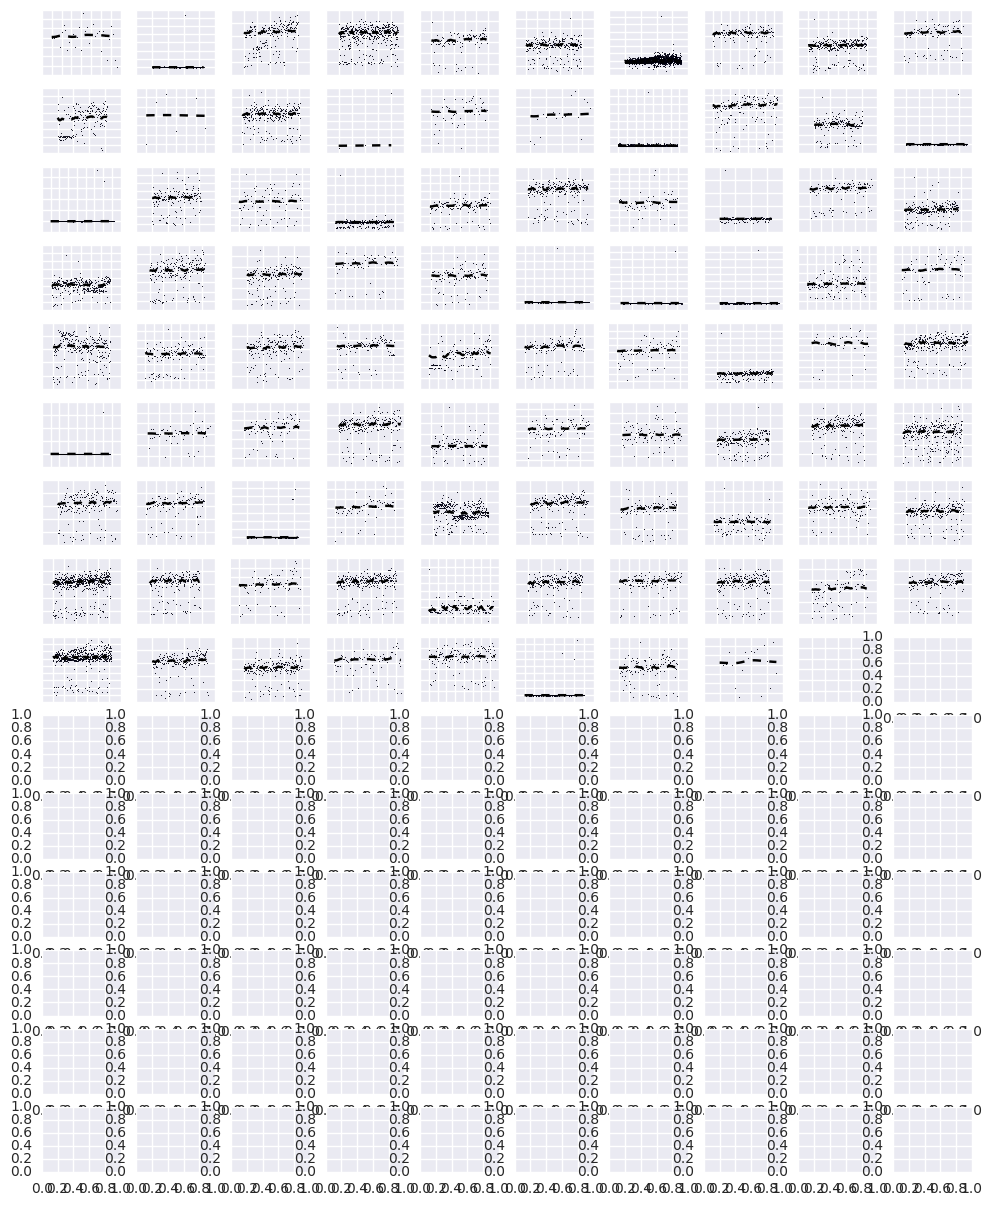

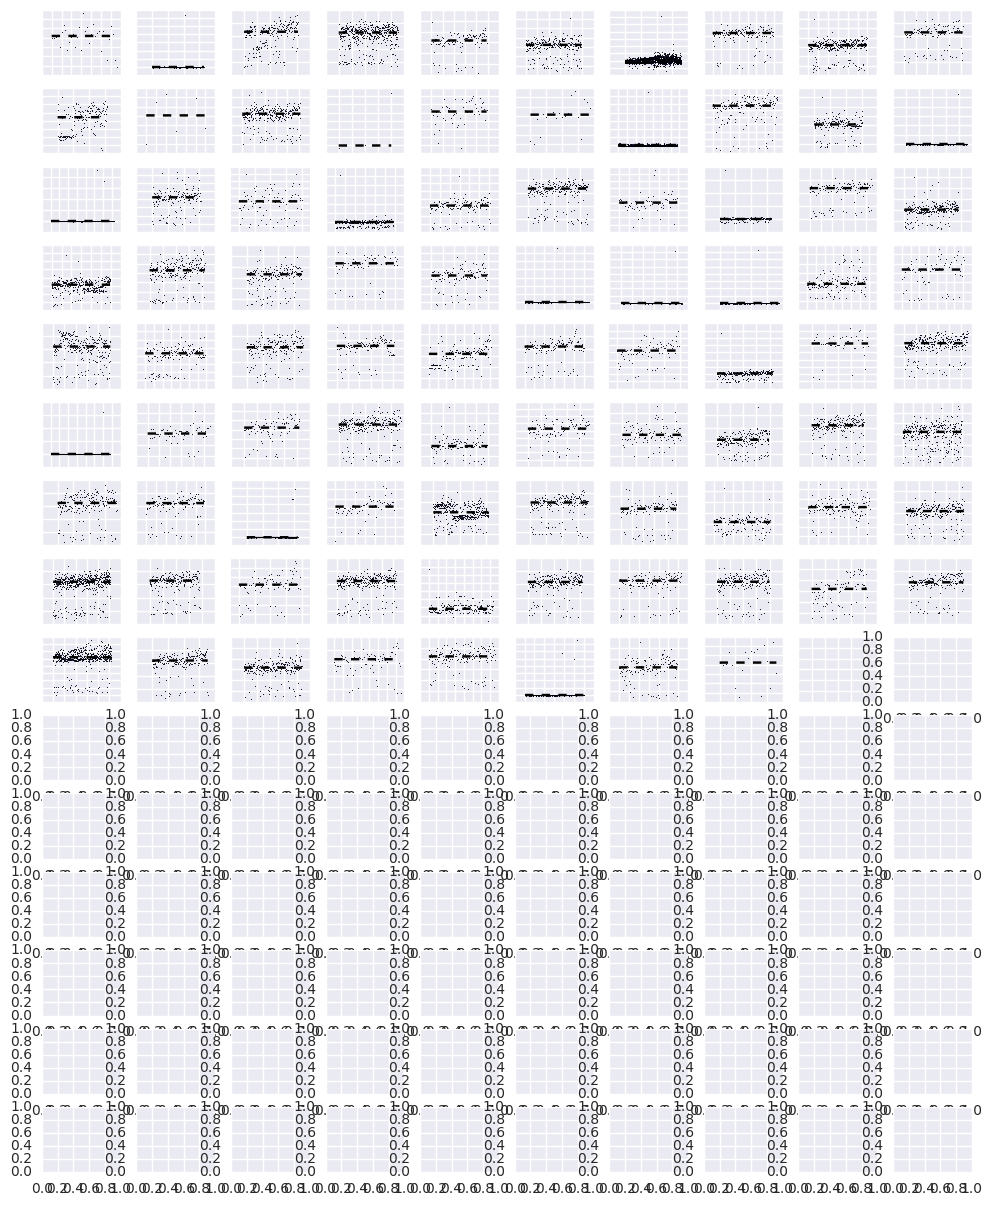

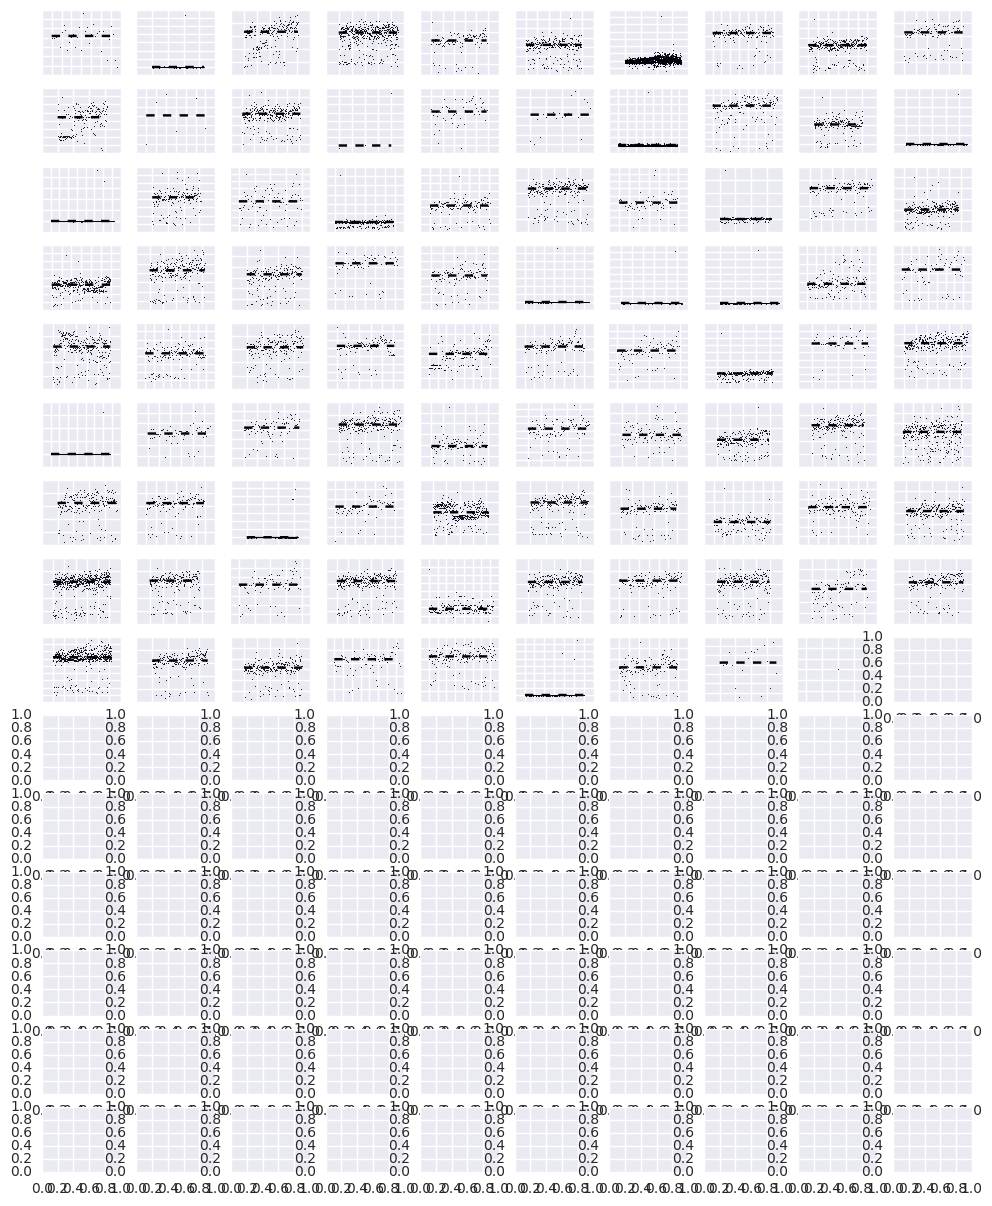

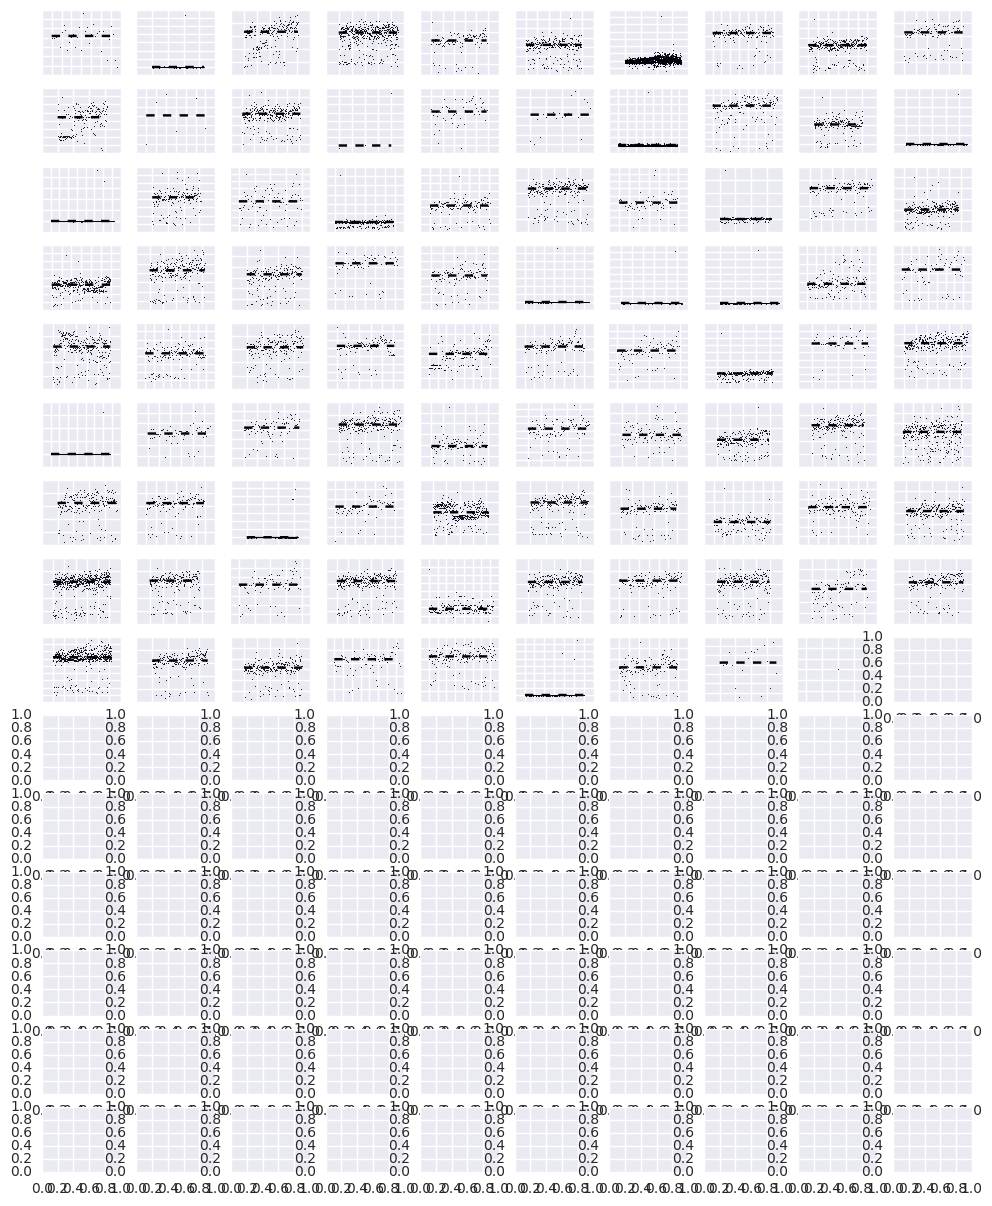

In [195]:
plt.show()

In [198]:
areas_stat['Price/full_sq'][88]

inf

In [74]:
print()

In [71]:
strings = []
for i in data_train.columns:
    condition = False
    for j in range(len(data_train)):
        if isinstance(data_train[i][j], str):
            condition = True
            break
    if condition: strings.append(i)
print(strings)

['timestamp', 'product_type', 'sub_area', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line', 'ecology']


In [27]:
# print(data_train['build_year'][9000:10000])
# data_train['build_year'][9000:10000].interpolate(method='cubic') #'polynomial', order=3

In [9]:
integer = []
for i in data_train.columns:
    condition = False
    for j in range(len(data_train)):
        if isinstance(data_train[i][j], np.int64):
            condition = True
            break
    if condition: integer.append(i)
print(integer)

['id', 'full_sq', 'raion_popul', 'children_preschool', 'preschool_education_centers_raion', 'children_school', 'school_education_centers_raion', 'school_education_centers_top_20_raion', 'healthcare_centers_raion', 'university_top_20_raion', 'sport_objects_raion', 'additional_education_raion', 'culture_objects_top_25_raion', 'shopping_centers_raion', 'office_raion', 'full_all', 'male_f', 'female_f', 'young_all', 'young_male', 'young_female', 'work_all', 'work_male', 'work_female', 'ekder_all', 'ekder_male', 'ekder_female', '0_6_all', '0_6_male', '0_6_female', '7_14_all', '7_14_male', '7_14_female', '0_17_all', '0_17_male', '0_17_female', '16_29_all', '16_29_male', '16_29_female', '0_13_all', '0_13_male', '0_13_female', 'ID_metro', 'ID_railroad_station_avto', 'ID_big_road1', 'ID_big_road2', 'ID_railroad_terminal', 'ID_bus_terminal', 'office_count_500', 'office_sqm_500', 'trc_count_500', 'trc_sqm_500', 'cafe_count_500', 'cafe_count_500_na_price', 'cafe_count_500_price_500', 'cafe_count_50

In [38]:
isinstance(data_train['indust_part'][1], np.int64)

False

In [39]:
type(data_train['indust_part'][1])

numpy.float64

In [41]:
len(integer)

157

In [42]:
298-157

141

In [8]:
float_features = []
for i in data_train.columns:
    condition = False
    for j in range(len(data_train)):
        if isinstance(data_train[i][j], np.float64):
            condition = True
            break
    if condition: float_features.append(i)
print(float_features)

['life_sq', 'floor', 'area_m', 'green_zone_part', 'indust_part', 'preschool_quota', 'school_quota', 'raion_build_count_with_material_info', 'build_count_block', 'build_count_wood', 'build_count_frame', 'build_count_brick', 'build_count_monolith', 'build_count_panel', 'build_count_foam', 'build_count_slag', 'build_count_mix', 'raion_build_count_with_builddate_info', 'build_count_before_1920', 'build_count_1921-1945', 'build_count_1946-1970', 'build_count_1971-1995', 'build_count_after_1995', 'metro_min_avto', 'metro_km_avto', 'metro_min_walk', 'metro_km_walk', 'kindergarten_km', 'school_km', 'park_km', 'green_zone_km', 'industrial_km', 'water_treatment_km', 'cemetery_km', 'incineration_km', 'railroad_station_walk_km', 'railroad_station_walk_min', 'ID_railroad_station_walk', 'railroad_station_avto_km', 'railroad_station_avto_min', 'public_transport_station_km', 'public_transport_station_min_walk', 'water_km', 'mkad_km', 'ttk_km', 'sadovoe_km', 'bulvar_ring_km', 'kremlin_km', 'big_road1_k

In [44]:
datanans = data_train[data_train.isnull().T.any().T]
len(datanans)

24429

In [45]:
len(data_train)

30471

In [46]:
len(datanans)/len(data_train)

0.8017131042630699

In [13]:
dict_nan1.keys()

dict_keys(['build_count_mix', 'metro_min_walk', 'railroad_station_walk_min', 'prom_part_5000', 'cafe_avg_price_1500', 'cafe_avg_price_1000', 'build_count_brick', 'build_count_slag', 'cafe_avg_price_2000', 'cafe_sum_5000_max_price_avg', 'raion_build_count_with_material_info', 'build_count_1921-1945', 'cafe_sum_1500_max_price_avg', 'metro_km_walk', 'cafe_sum_3000_max_price_avg', 'build_count_wood', 'ID_railroad_station_walk', 'cafe_sum_1000_max_price_avg', 'cafe_sum_3000_min_price_avg', 'build_count_1946-1970', 'cafe_avg_price_5000', 'school_quota', 'life_sq', 'floor', 'cafe_sum_2000_max_price_avg', 'cafe_avg_price_3000', 'build_count_1971-1995', 'raion_build_count_with_builddate_info', 'cafe_sum_2000_min_price_avg', 'build_count_before_1920', 'build_count_after_1995', 'build_count_frame', 'cafe_sum_5000_min_price_avg', 'build_count_block', 'build_count_panel', 'build_count_monolith', 'cafe_sum_1000_min_price_avg', 'preschool_quota', 'build_count_foam', 'railroad_station_walk_km', 'cafe_

In [7]:
def clean_nan(data, umbral=0.3):
    ''' umbral in per 1 '''
    dataclean = data
    for i in data.columns:
        percent = data[i].isnull().sum()/len(data)
        if percent >= umbral:
            dataclean = dataclean.drop(i,1)
    return dataclean
data_train = clean_nan(data_train)
data_test = clean_nan(data_test)
data_macro = clean_nan(data_macro)

In [14]:
dict_nan2.keys()

dict_keys(['railroad_station_walk_min', 'prom_part_5000', 'green_part_2000', 'cafe_avg_price_1500', 'cafe_avg_price_3000', 'build_count_slag', 'build_count_1921-1945', 'cafe_sum_1500_max_price_avg', 'build_count_wood', 'ID_railroad_station_walk', 'cafe_sum_2000_max_price_avg', 'cafe_sum_5000_max_price_avg', 'metro_km_walk', 'cafe_sum_1000_max_price_avg', 'build_count_1971-1995', 'raion_build_count_with_builddate_info', 'cafe_sum_3000_max_price_avg', 'build_count_before_1920', 'build_count_frame', 'build_count_block', 'build_count_panel', 'cafe_avg_price_1000', 'state', 'build_count_foam', 'build_count_mix', 'metro_min_walk', 'cafe_sum_3000_min_price_avg', 'build_year', 'build_count_brick', 'cafe_avg_price_2000', 'build_count_monolith', 'raion_build_count_with_material_info', 'cafe_avg_price_5000', 'school_quota', 'life_sq', 'build_count_1946-1970', 'cafe_sum_2000_min_price_avg', 'build_count_after_1995', 'cafe_sum_5000_min_price_avg', 'product_type', 'cafe_sum_1000_min_price_avg', 'pre

In [15]:
dict_nan3.keys()

dict_keys(['housing_fund_sqm', 'ppi', 'rent_price_3room_eco', 'net_capital_export', 'apartment_build', 'mortality', 'electric_stove_share', 'perinatal_mort_per_1000_cap', 'rent_price_1room_eco', 'brent', 'profitable_enterpr_share', 'invest_fixed_assets_phys', 'invest_fixed_assets', 'child_on_acc_pre_school', 'invest_fixed_capital_per_cap', 'water_pipes_share', 'usdrub', 'retail_trade_turnover_per_cap', 'turnover_catering_per_cap', 'employment', 'pop_natural_increase', 'deposits_rate', 'infant_mortarity_per_1000_cap', 'incidence_population', 'unemployment', 'pop_migration', 'gas_share', 'lodging_sqm_per_cap', 'hot_water_share', 'rent_price_4+room_bus', 'bandwidth_sports', 'share_own_revenues', 'load_of_teachers_school_per_teacher', 'marriages_per_1000_cap', 'average_life_exp', 'salary', 'sewerage_share', 'heating_share', 'fin_res_per_cap', 'seats_theather_rfmin_per_100000_cap', 'income_per_cap', 'load_on_doctors', 'gdp_deflator', 'students_state_oneshift', 'rts', 'rent_price_2room_eco',

In [17]:
['a', 'b'] + ['b','c']

['a', 'b', 'b', 'c']

In [30]:
datanans = data_train['build_count_mix'][data_train['build_count_mix'].isnull()]
datanans.index

Int64Index([ 2042,  2252,  2263,  2319,  2715,  2731,  2803,  2826,  2844,
             2874,
            ...
            30424, 30428, 30429, 30430, 30435, 30442, 30446, 30451, 30455,
            30468],
           dtype='int64', length=4991)

In [29]:
Xtrain = data_train['build_count_mix'][data_train['build_count_mix'].notnull()]
Xtrain.index

Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            30460, 30461, 30462, 30463, 30464, 30465, 30466, 30467, 30469,
            30470],
           dtype='int64', length=25480)

In [32]:
set(data_train['metro_min_walk'])

{nan,
 nan,
 2.5945051960000001,
 3.1486977510000003,
 4.5039513790000001,
 5.2160321060000001,
 5.6403155470000002,
 7.7187849970000002,
 8.5121042090000003,
 9.1531453650000003,
 9.261785132,
 11.52778764,
 11.92915309,
 12.87697584,
 14.134525699999998,
 14.33668831,
 16.496797409999999,
 17.351515399999997,
 15.636402889999999,
 18.172502420000001,
 18.325029749999999,
 18.11480924,
 18.805541259999998,
 20.918469479999999,
 21.17924524,
 21.463546919999999,
 26.865087160000002,
 27.678042980000001,
 28.071277649999999,
 29.393441150000001,
 21.409121970000001,
 22.334481310000001,
 23.436447659999999,
 24.29239063,
 34.185198159999999,
 26.782455970000001,
 36.84571554,
 37.571124429999998,
 36.673421730000001,
 36.574909259999998,
 37.679661490000001,
 32.302803670000003,
 33.805317070000001,
 34.993288280000002,
 35.758498959999997,
 45.257574349999999,
 37.367327950000004,
 47.762268849999998,
 48.060595890000002,
 49.06654863,
 48.678680720000003,
 42.867891589999999,
 48.1680

In [3]:
data_train['max_floor'][0].isnull()

AttributeError: 'numpy.float64' object has no attribute 'isnull'

In [11]:
# def feature_type(data, data_type):
#     feature_list = []
#     for i in data.columns:
#         condition = False
#         for j,k in zip(range(len(data[i])), data[i].isnull()):
#             if k: pass
#             elif isinstance(data[i][j], data_type):
#                 condition = True
#                 break
#             else: break
#         if condition:
#             feature_list.append(i)
#     return feature_list

def feature_type(data,data_type):
    feature_list = []
    for i in data.columns:
        if isinstance(data[i][0], data_type):
            feature_list.append(i)
    return feature_list

In [15]:
print(feature_type(data_train, np.int))

[]


In [10]:
type(data_train['max_floor'][0])

numpy.float64

In [27]:
data_train['max_floor'].describe()

count    20899.000000
mean        12.558974
std          6.756550
min          0.000000
25%          9.000000
50%         12.000000
75%         17.000000
max        117.000000
Name: max_floor, dtype: float64

In [19]:
data_train['full_sq'][data_train['full_sq'].isnull()].index

Int64Index([], dtype='int64')

In [21]:
np.int64(4.45)

4

In [24]:
data_train[:][:25].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Columns: 292 entries, id to price_doc
dtypes: float64(119), int64(157), object(16)
memory usage: 57.1+ KB


In [7]:
for i in range(100):
    print(random.gauss(5,2))

9.34111824279114
2.2970423493525107
3.869213762078515
5.947437380821113
8.188888402336243
7.418323944337287
5.2428151311493885
6.688005708564951
9.839551420546996
5.230338708189683
7.357223653717336
6.017916645599105
1.5892694985482807
6.370179826250343
3.7969357448662744
4.690960101220155
4.450146265861007
5.596559237920183
6.07691741051644
6.023247147486073
2.6937619365343406
4.92398188358203
4.238557319940638
1.5204399267885265
4.420300527624611
5.178562007389034
8.18692964077176
3.696313048008859
-0.7115906504884304
4.526804527186832
8.363059972880203
7.166392085250604
-0.763194680761778
7.280173170871969
4.425477713621801
4.932925312669922
5.605783687135329
5.226447878851658
6.512408161170004
5.425966109931726
7.56385266158855
-0.10705477962065224
6.034937838431678
5.5785440487061395
3.753951905840731
4.896925773243363
6.431186810766717
1.9262697405945781
1.7741742987034277
5.270574565965848
4.310449189276573
4.1622902239118025
6.141584440830467
5.417553864259537
3.817611550315856

In [14]:
np.random.normal(5, 2)

2.396320895738377

In [18]:
by = data_train.build_year.isnull()
st = data_train.state.isnull()
by_index = []
st_index = []
# for i in by:
#     if i:
#         by_index.append(i.idex)
# for i in st:
#     if i:
#         st_index.append(i.index)
st

0         True
1         True
2         True
3         True
4         True
5         True
6         True
7         True
8         True
9         True
10        True
11        True
12        True
13        True
14        True
15        True
16        True
17        True
18        True
19        True
20        True
21        True
22        True
23        True
24        True
25        True
26        True
27        True
28        True
29        True
         ...  
30441    False
30442    False
30443    False
30444    False
30445    False
30446    False
30447     True
30448     True
30449    False
30450     True
30451    False
30452    False
30453    False
30454    False
30455     True
30456    False
30457    False
30458    False
30459    False
30460    False
30461    False
30462    False
30463    False
30464    False
30465    False
30466    False
30467    False
30468    False
30469    False
30470    False
Name: state, dtype: bool

In [6]:
for i in set(data_test.sub_area):
    if i not in set(data_train.sub_area):
        print(i)

In [5]:
for i in set(data_train.sub_area):
    if i not in set(data_test.sub_area):
        print(i)

Poselenie Klenovskoe
